In [1]:
import h5py
h5_path = '/data/vision/billf/scratch/pablomer/data/test_neighbours_v2.h5'


N_EXAMPLES = 8
with h5py.File(h5_path, 'r') as f:
    legacy_tensor = f['images_legacy'][:N_EXAMPLES]
    hsc_tensor = f['images_hsc'][:N_EXAMPLES]


In [5]:
leg_im = legacy_tensor[0]
hsc_im = hsc_tensor[0]
print(leg_im.shape)

(4, 160, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3182989..3.6865942].


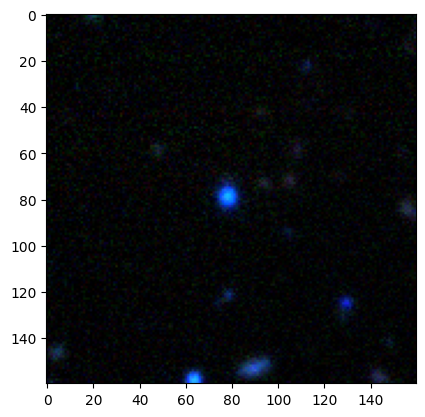

In [6]:
import matplotlib.pyplot as plt

plt.imshow(hsc_im.transpose(1, 2, 0)[:, :, :3])

In [ ]:
"""
Extract AION embeddings from neighbours HDF5: encode HSC+Legacy with AION,
save full embeddings, mean embeddings, and all instrument metadata (same schema as prepare_neighbors).

Run from galaxy_model/ or aion_benchmark/:
  python aion_benchmark/extract_latents_aion.py
"""
import os
import shutil
import sys
import tempfile
from pathlib import Path

_here = Path(__file__).resolve().parent
_src = _here.parent
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import h5py
import numpy as np
import torch
from torch.utils.data import Subset
from tqdm import tqdm

from aion import AION
from aion.codecs import CodecManager
from aion.modalities import LegacySurveyImage, HSCImage

from neighbors import NeighborsSimpleDataset

# Neighbors HDF5 (same as prepare_neighbors)
NEIGHBORS_HDF5 = "/data/vision/billf/scratch/pablomer/data/neighbours_v2.h5"
OUTPUT_H5 = _here / "downstream_aion_neighbors.h5"

# Cap number of examples (None = use full dataset)
NUM_EXAMPLES = 2
BATCH_SIZE = 2
SEED = 42
NUM_ENCODER_TOKENS = 1200  # HSC + Legacy combined
NUM_ENCODER_TOKENS_SINGLE = 600  # Legacy-only or HSC-only
DEVICE = "cpu"


def _labels_from_metadata_list(metadata_list):
    """
    Build labels dict from list of metadata dicts (same logic as prepare_neighbors).
    Includes keys whose values are numeric (int/float) and stack into arrays.
    Returns (labels_n, label_columns).
    """
    if not metadata_list:
        return {}, []

    keys = list(metadata_list[0].keys())
    labels_n = {}
    valid_columns = []

    for col in keys:
        try:
            vals = [m[col] for m in metadata_list]
            arr = np.array(vals)
            if arr.dtype.kind in "iuflb" and arr.shape[0] == len(metadata_list):
                labels_n[col] = arr.astype(np.float32) if arr.dtype.kind in "f" else arr
                valid_columns.append(col)
            elif arr.dtype.kind in "iuflb" and arr.ndim == 2 and arr.shape[0] == len(metadata_list):
                labels_n[col] = arr.astype(np.float32)
                valid_columns.append(col)
            else:
                pass
        except (TypeError, ValueError):
            pass

    return labels_n, valid_columns


def main():
    print("Device:", DEVICE)
    model = AION.from_pretrained("polymathic-ai/aion-base").to(DEVICE)
    codec_manager = CodecManager(device=DEVICE)

    print(f"Loading NeighborsSimpleDataset from {NEIGHBORS_HDF5}...")
    full_dataset = NeighborsSimpleDataset(hdf5_path=NEIGHBORS_HDF5)
    n_total = len(full_dataset)
    n_use = min(NUM_EXAMPLES, n_total) if NUM_EXAMPLES is not None else n_total
    dataset = Subset(full_dataset, range(n_use))
    print(f"Using {n_use} examples")

    # Get metadata for labels (same order as dataset)
    metadata_collected = []
    for i in range(len(dataset)):
        _, _, meta = dataset[i]
        metadata_collected.append(meta)

    labels_n, label_columns = _labels_from_metadata_list(metadata_collected)
    print(f"Built {len(label_columns)} label columns from metadata")

    # AION expects flux in a specific format; NeighborsSimpleDataset returns preprocessed (normalized) images.
    # We need raw flux from H5 for AION. Load raw by index_mmu.
    with h5py.File(NEIGHBORS_HDF5, "r") as f:
        indexes_mmu = np.where(f["source_type"][:] == 0)[0][:n_use]
        all_embeddings = []
        all_embeddings_mean = []
        all_embeddings_mean_legacy = []
        all_embeddings_mean_hsc = []

        for start in tqdm(range(0, len(indexes_mmu), BATCH_SIZE), desc="Encoding"):
            end = min(start + BATCH_SIZE, len(indexes_mmu))
            indices = indexes_mmu[start:end]

            legacy_tensor = torch.from_numpy(f["images_legacy"][indices]).to(DEVICE)
            hsc_tensor = torch.from_numpy(f["images_hsc"][indices]).to(DEVICE)

            image_leg = LegacySurveyImage(
                flux=legacy_tensor,
                bands=["DES-G", "DES-R", "DES-I", "DES-Z"],
            )
            image_hsc = HSCImage(
                flux=hsc_tensor,
                bands=["HSC-G", "HSC-R", "HSC-I", "HSC-Z", "HSC-Y"],
            )
            tokens_hsc_leg = codec_manager.encode(image_hsc, image_leg)
            tokens_leg = codec_manager.encode(image_leg)
            tokens_hsc = codec_manager.encode(image_hsc)

            with torch.no_grad():
                emb_hsc_leg = model.encode(tokens_hsc_leg, num_encoder_tokens=NUM_ENCODER_TOKENS)
                emb_leg = model.encode(tokens_leg, num_encoder_tokens=NUM_ENCODER_TOKENS_SINGLE)
                emb_hsc = model.encode(tokens_hsc, num_encoder_tokens=NUM_ENCODER_TOKENS_SINGLE)
            # emb_*: [B, T, D]
            all_embeddings.append(emb_hsc_leg.cpu().numpy())
            all_embeddings_mean.append(emb_hsc_leg.mean(dim=1).cpu().numpy())
            all_embeddings_mean_legacy.append(emb_leg.mean(dim=1).cpu().numpy())
            all_embeddings_mean_hsc.append(emb_hsc.mean(dim=1).cpu().numpy())

        embeddings = np.concatenate(all_embeddings, axis=0)
        embeddings_mean = np.concatenate(all_embeddings_mean, axis=0)
        embeddings_mean_legacy = np.concatenate(all_embeddings_mean_legacy, axis=0)
        embeddings_mean_hsc = np.concatenate(all_embeddings_mean_hsc, axis=0)

    print("Embeddings shape:", embeddings.shape)
    print("Embeddings mean shape:", embeddings_mean.shape)
    print("Embeddings mean legacy shape:", embeddings_mean_legacy.shape)
    print("Embeddings mean HSC shape:", embeddings_mean_hsc.shape)

    # Save to HDF5 (same label layout as prepare_neighbors for compatibility with predict_aion).
    # Write to a temp file on local disk first, then move to final path to avoid HDF5 file-lock
    # failures on network filesystems (BlockingIOError: unable to lock file, errno 11).
    # OUTPUT_H5.parent.mkdir(parents=True, exist_ok=True)
    # tmp_fd, tmp_path = tempfile.mkstemp(suffix=".h5", prefix="downstream_aion_", dir=tempfile.gettempdir())
    # os.close(tmp_fd)
    # try:
    #     with h5py.File(tmp_path, "w") as f:
    #         f.create_dataset("embeddings", data=embeddings, compression="gzip", compression_opts=4)
    #         f.create_dataset("embeddings_mean", data=embeddings_mean, compression="gzip", compression_opts=4)
    #         f.create_dataset("embeddings_mean_legacy", data=embeddings_mean_legacy, compression="gzip", compression_opts=4)
    #         f.create_dataset("embeddings_mean_hsc", data=embeddings_mean_hsc, compression="gzip", compression_opts=4)
    #         for col in label_columns:
    #             data = labels_n[col]
    #             f.create_dataset(
    #                 f"labels/{col}",
    #                 data=data,
    #                 compression="gzip",
    #                 compression_opts=4,
    #             )
    #         f.attrs["num_examples"] = n_use
    #         f.attrs["label_columns"] = list(label_columns)
    #         f.attrs["embedding_shape"] = embeddings.shape
    #         f.attrs["embedding_mean_shape"] = embeddings_mean.shape
    #         f.attrs["embedding_mean_legacy_shape"] = embeddings_mean_legacy.shape
    #         f.attrs["embedding_mean_hsc_shape"] = embeddings_mean_hsc.shape
    #     shutil.move(tmp_path, OUTPUT_H5)
    # except Exception:
    #     if os.path.exists(tmp_path):
    #         try:
    #             os.unlink(tmp_path)
    #         except OSError:
    #             pass
    #     raise

    # print(f"Saved: {OUTPUT_H5} (embeddings, embeddings_mean, embeddings_mean_legacy, embeddings_mean_hsc, {len(label_columns)} labels)")


if __name__ == "__main__":
    main()
